# Figure S1 · Reliability-selected Cluster OOD protocol

> Supplementary figure. Independently select Cluster OOD k in ESM embedding space via **cluster-size / reliability criteria** (not by model AUROC). This notebook is **self-contained** and no longer depends on `notebooks/scripts/figS1_*.py`.

**Boundary with fig3**
- This notebook may write: `results/notebooks/cluster_validation/*`, `work/results/cluster_sensitivity.csv`
- This notebook is **read-only** on fig3 artifacts: `work/results/probe_protocol_full_selected_k.csv` (and compatible `probe_ood_full_selected_k.csv`)
- This notebook does **not write** `probe_protocol_full_selected_k.csv` / `probe_ood_full_selected_k.csv`

**Panels**
- **S1A** cluster-size criterion
- **S1B** reliability criterion
- **S1C** selected-k cluster size distribution
- **S1D** subtype OOD vs cluster OOD complementarity (reads fig3 tables)
- **Sensitivity** algo × k cluster-OOD sweep


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / 'work' / 'results').exists() else CWD.parent
assert (PROJECT_ROOT / 'work' / 'results').exists(), f'cannot locate work/results from {CWD}'

RES = PROJECT_ROOT / 'work' / 'results'
PREP = PROJECT_ROOT / 'work' / 'prepared'
EMB = PROJECT_ROOT / 'work' / 'emb_full'
REF_DIR = PROJECT_ROOT / 'work' / 'hivdb_full' / 'refs'
FIG_DIR = PROJECT_ROOT / 'figures' / 'manuscript' / 'supp_cluster'
OUT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / 'cluster_validation'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# fig3-owned files: READ ONLY
PROTOCOL_CSV = RES / 'probe_protocol_full_selected_k.csv'
OOD_CSV = RES / 'probe_ood_full_selected_k.csv'
SENS_CSV = RES / 'cluster_sensitivity.csv'
K_CSV = OUT_DIR / 'selected_cluster_k.csv'

SURFACE, INK, INK2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e6e5e1'
M_COLOR = {'binary': '#6f4bd8', 'esm_lr': '#2a78d6', 'esm_lgb': '#eb6834'}
M_LABEL = {'binary': 'binary mutation', 'esm_lr': 'ESM-linear', 'esm_lgb': 'ESM-nonlinear'}
CLASS_COLOR = {'PI': '#2a78d6', 'NRTI': '#1baf7a', 'NNRTI': '#eda100', 'INI': '#9467bd'}
MAIN_CLASSES = ['PI', 'NRTI', 'NNRTI', 'INI']
GENE_OF = {'PI': 'PR', 'NRTI': 'RT', 'NNRTI': 'RT', 'INI': 'IN'}
DRUGS = {
    'PI': ['FPV', 'ATV', 'IDV', 'LPV', 'NFV', 'SQV', 'TPV', 'DRV'],
    'NRTI': ['3TC', 'ABC', 'AZT', 'D4T', 'DDI', 'TDF'],
    'NNRTI': ['EFV', 'ETR', 'NVP', 'RPV'],
    'INI': ['RAL', 'EVG', 'DTG', 'BIC', 'CAB'],
}

SEED = 42
CANDIDATE_K = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30]
MIN_P10 = 30.0
MIN_FRAC_GE30 = 0.90
MIN_FRAC_BOTH = 0.60
SELECTION_RULE = (
    'largest k satisfying p10_cluster_size>=30, '
    'frac_clusters_ge30>=0.90, '
    'frac_clusters_both_classes>=0.60'
)
SELECTION_SCOPE = (
    'class-level k-means on ESM embeddings; '
    'reliability evaluated on drug-specific valid samples'
)

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.size': 11, 'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': False,
    'font.family': 'DejaVu Sans',
})

print('PROJECT_ROOT =', PROJECT_ROOT)
print('fig3 read-only:', PROTOCOL_CSV.name, '/', OOD_CSV.name)
print('figS1 write dir:', OUT_DIR)


PROJECT_ROOT = /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2
fig3 read-only: probe_protocol_full_selected_k.csv / probe_ood_full_selected_k.csv
figS1 write dir: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2/results/notebooks/cluster_validation


## 1 · Reliability analysis (formerly `figS1_select_cluster_k.py`)

Class-level KMeans on ESM embeddings; evaluate held-out cluster size / class balance on per-drug valid samples.  
Selection rule: the **largest k** that passes thresholds.

Outputs (figS1 / downstream k contract only; **does not write fig3 probe tables**):
- `selected_cluster_k.csv` (k contract read by fig3)
- `k_reliability_metrics.csv` / `k_reliability_per_drug.csv`
- `cluster_sizes_by_k.csv` / `cluster_sizes_selected_k.csv`


In [2]:
def read_fasta(path: Path) -> str:
    return ''.join(
        line.strip()
        for line in path.read_text().splitlines()
        if line and not line.startswith('>')
    )


def build_refs() -> dict[str, str]:
    pol = read_fasta(REF_DIR / 'P04585.fasta')
    gag = read_fasta(REF_DIR / 'P04591.fasta')
    spec = {
        'PR': (pol, 489, 587, {3: 'I'}),
        'RT': (pol, 588, 1187, {214: 'F', 570: 'E'}),
        'IN': (pol, 1148, 1435, {10: 'E', 72: 'I', 123: 'S', 124: 'T', 127: 'K', 232: 'D'}),
    }
    out: dict[str, str] = {}
    for gene, (src, start, end, patch) in spec.items():
        seq = list(src[start - 1: end])
        for pos, aa in patch.items():
            seq[pos - 1] = aa
        out[gene] = ''.join(seq)
    return out


def load_emb(gene: str):
    mean = np.load(EMB / f'{gene}_mean.npy')
    seqs = json.loads((EMB / f'{gene}_seqs.json').read_text(encoding='utf-8'))['sequences']
    return {s: i for i, s in enumerate(seqs)}, mean


def cluster_labels(x_emb: np.ndarray, requested_k: int):
    k_eff = min(requested_k, max(2, len(x_emb) // 20))
    labels = KMeans(n_clusters=k_eff, n_init=10, random_state=SEED).fit_predict(x_emb)
    return labels, k_eff


def run_reliability_selection():
    cache = {}
    size_rows = []
    per_drug_rows = []

    for cls, drugs in DRUGS.items():
        gene = GENE_OF[cls]
        if gene not in cache:
            cache[gene] = load_emb(gene)
        idx, mean = cache[gene]
        df = pd.read_csv(PREP / f'{cls}.csv', dtype={'SeqID': str, 'PtID': str})
        emb_row = np.array([idx.get(s, -1) for s in df['sequence'].tolist()])
        class_mask = emb_row >= 0
        if int(class_mask.sum()) < 2:
            print(f'=== {cls}: skip (no embeddings) ===', flush=True)
            continue

        for requested_k in CANDIDATE_K:
            print(f'=== {cls} k={requested_k} ===', flush=True)
            class_lab, k_eff = cluster_labels(mean[emb_row[class_mask]], requested_k)
            full_labels = np.full(len(df), -1, dtype=int)
            full_labels[np.where(class_mask)[0]] = class_lab

            for drug in drugs:
                y = pd.to_numeric(df[f'{drug}_label'], errors='coerce').to_numpy()
                valid = (~np.isnan(y)) & (emb_row >= 0)
                yv = y[valid].astype(int)
                if len(np.unique(yv)) < 2:
                    continue
                labels = full_labels[valid]
                ge30, both, sizes = [], [], []
                for c in np.unique(labels):
                    m = labels == c
                    n = int(m.sum())
                    n_res = int(yv[m].sum())
                    n_sus = n - n_res
                    both_classes = n_res > 0 and n_sus > 0
                    sizes.append(n)
                    ge30.append(n >= 30)
                    both.append(both_classes)
                    size_rows.append({
                        'class': cls, 'drug': drug, 'gene': gene,
                        'requested_k': requested_k, 'k_eff': k_eff, 'cluster': int(c),
                        'cluster_size': n, 'n_resistant': n_res, 'n_susceptible': n_sus,
                        'both_classes': both_classes,
                    })
                sizes_arr = np.asarray(sizes, float)
                per_drug_rows.append({
                    'class': cls, 'drug': drug, 'gene': gene,
                    'requested_k': requested_k, 'k_eff': k_eff,
                    'n': int(valid.sum()), 'n_clusters': int(len(sizes)),
                    'min_cluster_size': int(sizes_arr.min()),
                    'p10_cluster_size': float(np.percentile(sizes_arr, 10)),
                    'median_cluster_size': float(np.median(sizes_arr)),
                    'frac_clusters_ge30': float(np.mean(ge30)),
                    'frac_clusters_both_classes': float(np.mean(both)),
                    'drug_all_clusters_ge30': bool(all(ge30)),
                    'drug_p10_ge30': bool(np.percentile(sizes_arr, 10) >= MIN_P10),
                })
        print(f'  {cls} all k done', flush=True)

    sizes_df = pd.DataFrame(size_rows)
    per_df = pd.DataFrame(per_drug_rows)
    metric_rows = []
    for k, g in per_df.groupby('requested_k'):
        row = {
            'k': int(k),
            'n_drugs': int(len(g)),
            'median_cluster_size': float(g['median_cluster_size'].median()),
            'p10_cluster_size': float(g['p10_cluster_size'].median()),
            'min_p10_cluster_size': float(g['p10_cluster_size'].min()),
            'frac_clusters_ge30': float(g['frac_clusters_ge30'].mean()),
            'frac_clusters_both_classes': float(g['frac_clusters_both_classes'].mean()),
            'frac_drugs_all_clusters_ge30': float(g['drug_all_clusters_ge30'].mean()),
            'frac_drugs_p10_ge30': float(g['drug_p10_ge30'].mean()),
        }
        row['passes_reliability'] = bool(
            row['p10_cluster_size'] >= MIN_P10
            and row['frac_clusters_ge30'] >= MIN_FRAC_GE30
            and row['frac_clusters_both_classes'] >= MIN_FRAC_BOTH
        )
        row['selected'] = False
        metric_rows.append(row)

    metrics = pd.DataFrame(metric_rows).sort_values('k').reset_index(drop=True)
    passing = metrics[metrics['passes_reliability']]
    if passing.empty:
        raise RuntimeError('No candidate k passed reliability thresholds')
    k_star = int(passing['k'].max())
    metrics.loc[metrics['k'] == k_star, 'selected'] = True

    selected = metrics[metrics['selected']].copy()
    selected['selection_rule'] = SELECTION_RULE
    selected['selection_scope'] = SELECTION_SCOPE
    float_cols = [
        c for c in selected.columns
        if c not in {'k', 'n_drugs', 'passes_reliability', 'selected', 'selection_rule', 'selection_scope'}
    ]
    for col in float_cols:
        selected[col] = pd.to_numeric(selected[col], errors='coerce').round(12)

    selected_sizes = sizes_df[sizes_df['requested_k'] == k_star].copy()
    return metrics, per_df, sizes_df, selected_sizes, selected, k_star


print('Running reliability selection analysis ...', flush=True)
metrics, per_drug, cluster_sizes_all, cluster_sizes, selected_df, K_STAR = run_reliability_selection()
selected = selected_df.iloc[0]

# Write ONLY figS1 / k-contract artifacts. Never touch fig3 probe tables.
selected_df.to_csv(K_CSV, index=False)
metrics.to_csv(OUT_DIR / 'k_reliability_metrics.csv', index=False)
per_drug.to_csv(OUT_DIR / 'k_reliability_per_drug.csv', index=False)
cluster_sizes_all.to_csv(OUT_DIR / 'cluster_sizes_by_k.csv', index=False)
cluster_sizes.to_csv(OUT_DIR / 'cluster_sizes_selected_k.csv', index=False)

print('\nReliability metrics:')
print(
    metrics[[
        'k', 'p10_cluster_size', 'frac_clusters_ge30', 'frac_clusters_both_classes',
        'passes_reliability', 'selected',
    ]].round(4).to_string(index=False)
)
print(f'\nSelected k = {K_STAR}')
print('wrote:', K_CSV.name, 'k_reliability_*.csv', 'cluster_sizes_*.csv')
print('did NOT write fig3 files:', PROTOCOL_CSV.name, OOD_CSV.name)


Running reliability selection analysis ...
=== PI k=2 ===
=== PI k=3 ===
=== PI k=4 ===
=== PI k=5 ===
=== PI k=6 ===
=== PI k=8 ===
=== PI k=10 ===
=== PI k=12 ===
=== PI k=15 ===
=== PI k=20 ===
=== PI k=25 ===
=== PI k=30 ===
  PI all k done
=== NRTI k=2 ===
=== NRTI k=3 ===
=== NRTI k=4 ===
=== NRTI k=5 ===
=== NRTI k=6 ===
=== NRTI k=8 ===
=== NRTI k=10 ===
=== NRTI k=12 ===
=== NRTI k=15 ===
=== NRTI k=20 ===
=== NRTI k=25 ===
=== NRTI k=30 ===
  NRTI all k done
=== NNRTI k=2 ===
=== NNRTI k=3 ===
=== NNRTI k=4 ===
=== NNRTI k=5 ===
=== NNRTI k=6 ===
=== NNRTI k=8 ===
=== NNRTI k=10 ===
=== NNRTI k=12 ===
=== NNRTI k=15 ===
=== NNRTI k=20 ===
=== NNRTI k=25 ===
=== NNRTI k=30 ===
  NNRTI all k done
=== INI k=2 ===
=== INI k=3 ===
=== INI k=4 ===
=== INI k=5 ===
=== INI k=6 ===
=== INI k=8 ===
=== INI k=10 ===
=== INI k=12 ===
=== INI k=15 ===
=== INI k=20 ===
=== INI k=25 ===
=== INI k=30 ===
  INI all k done

Reliability metrics:
 k  p10_cluster_size  frac_clusters_ge30  frac_cl

## S1A · Cluster-size criterion

As k grows, held-out clusters fragment; require p10 cluster size ≥ 30 and take the largest k that passes reliability thresholds.


 k  median_cluster_size  p10_cluster_size  passes_reliability  selected
 2               1233.0             513.8                True     False
 3               1058.0             453.8                True     False
 4                637.0             221.8                True     False
 5                475.0             191.4                True     False
 6                334.0             202.0                True     False
 8                301.5             187.8                True     False
10                254.0             153.3                True     False
12                209.0             131.9                True      True
15                162.0             119.6               False     False
20                126.5              49.0               False     False
25                101.0              31.2               False     False
30                 80.0              15.8               False     False


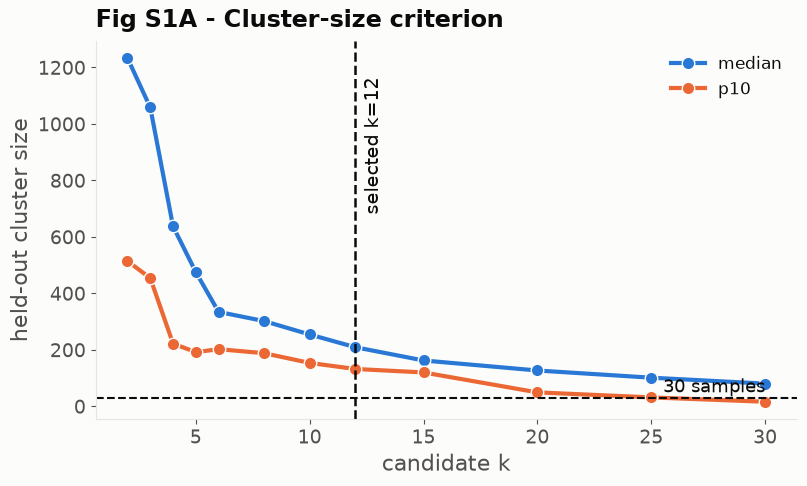

In [3]:
print(metrics[['k', 'median_cluster_size', 'p10_cluster_size', 'passes_reliability', 'selected']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(metrics['k'], metrics['median_cluster_size'], '-o', lw=3.0, ms=9, color='#2a78d6', markeredgecolor=SURFACE, label='median')
ax.plot(metrics['k'], metrics['p10_cluster_size'], '-o', lw=3.0, ms=9, color='#eb6834', markeredgecolor=SURFACE, label='p10')
ax.axhline(30, color=INK, lw=1.5, ls='--')
ax.axvline(K_STAR, color=INK, lw=1.8, ls='--')
ax.text(K_STAR + 0.35, ax.get_ylim()[1] * 0.90, f'selected k={K_STAR}', rotation=90, va='top', ha='left', fontsize=14, color=INK)
ax.text(metrics['k'].max(), 34, '30 samples', ha='right', va='bottom', fontsize=13, color=INK)
ax.set_xlabel('candidate k', fontsize=16)
ax.set_ylabel('held-out cluster size', fontsize=16)
ax.set_title('Fig S1A - Cluster-size criterion', loc='left', fontsize=17, color=INK, pad=10, fontweight='bold')
ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=14)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1A_cluster_size_criterion.png', dpi=150, bbox_inches='tight')
plt.show()


## S1B · Reliability criterion

`frac_clusters_ge30 ≥ 0.90` and `frac_clusters_both_classes ≥ 0.60`.


 k  frac_clusters_ge30  frac_clusters_both_classes  passes_reliability  selected
 2               1.000                       1.000                True     False
 3               1.000                       0.986                True     False
 4               1.000                       0.935                True     False
 5               0.983                       0.939                True     False
 6               0.964                       0.942                True     False
 8               0.946                       0.918                True     False
10               0.926                       0.930                True     False
12               0.909                       0.935                True      True
15               0.893                       0.899               False     False
20               0.846                       0.898               False     False
25               0.821                       0.876               False     False
30               0.767      

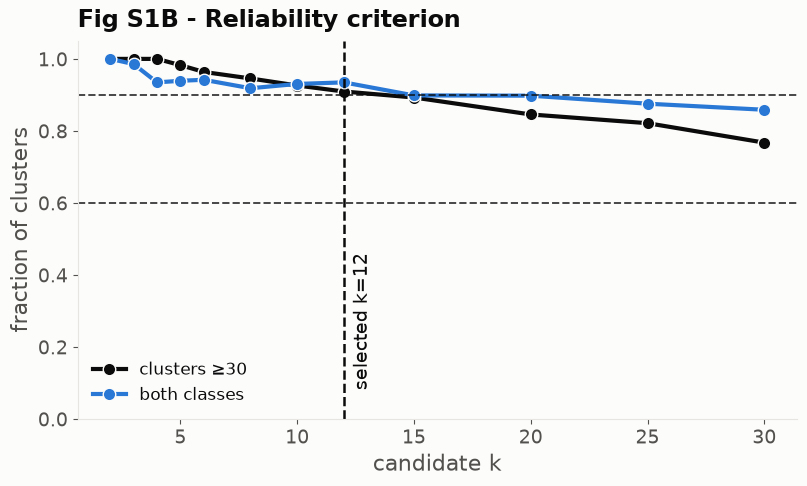

In [4]:
print(metrics[['k', 'frac_clusters_ge30', 'frac_clusters_both_classes', 'passes_reliability', 'selected']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(metrics['k'], metrics['frac_clusters_ge30'], '-o', lw=3.0, ms=9, color=INK, markeredgecolor=SURFACE, label='clusters ≥30')
ax.plot(metrics['k'], metrics['frac_clusters_both_classes'], '-o', lw=3.0, ms=9, color='#2a78d6', markeredgecolor=SURFACE, label='both classes')
ax.axhline(0.90, color=INK, lw=1.4, ls='--', alpha=0.75)
ax.axhline(0.60, color=INK, lw=1.4, ls='--', alpha=0.75)
ax.axvline(K_STAR, color=INK, lw=1.8, ls='--')
ax.text(K_STAR + 0.35, 0.08, f'selected k={K_STAR}', rotation=90, va='bottom', ha='left', fontsize=14, color=INK)
ax.set_ylim(0, 1.05)
ax.set_xlabel('candidate k', fontsize=16)
ax.set_ylabel('fraction of clusters', fontsize=16)
ax.set_title('Fig S1B - Reliability criterion', loc='left', fontsize=17, color=INK, pad=10, fontweight='bold')
ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=14)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1B_reliability_criterion.png', dpi=150, bbox_inches='tight')
plt.show()


## S1C · Selected-k cluster size distribution

Per-drug held-out cluster sizes at selected k; most should sit above the 30-sample reference line.


       count   min    25%    50%    75%    max
class                                         
INI     60.0   7.0   33.0   78.5  124.5  332.0
NNRTI   48.0   7.0   34.5  101.5  207.8  504.0
NRTI    72.0  62.0  180.0  208.5  229.0  454.0
PI      96.0  85.0  193.5  265.5  331.0  564.0


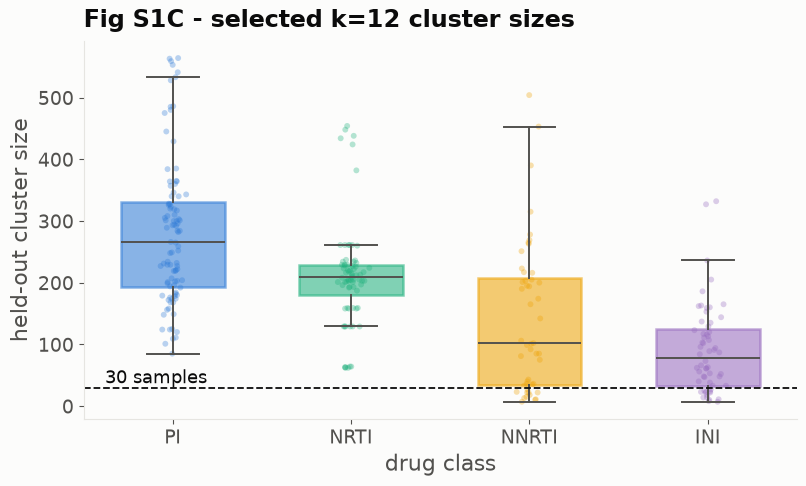

In [5]:
summary = cluster_sizes.groupby('class')['cluster_size'].describe()[['count', 'min', '25%', '50%', '75%', 'max']]
print(summary.round(1).to_string())

fig, ax = plt.subplots(figsize=(8.2, 5.0))
data = [cluster_sizes.loc[cluster_sizes['class'] == cls, 'cluster_size'].values for cls in MAIN_CLASSES]
bp = ax.boxplot(data, patch_artist=True, widths=0.58, showfliers=False)
ax.set_xticks(range(1, len(MAIN_CLASSES) + 1))
ax.set_xticklabels(MAIN_CLASSES)
for box, cls in zip(bp['boxes'], MAIN_CLASSES):
    box.set_facecolor(CLASS_COLOR[cls])
    box.set_alpha(0.55)
    box.set_edgecolor(CLASS_COLOR[cls])
    box.set_linewidth(1.8)
for key in ['whiskers', 'caps', 'medians']:
    for obj in bp[key]:
        obj.set_color(INK2)
        obj.set_linewidth(1.4)
rng = np.random.default_rng(42)
for i, cls in enumerate(MAIN_CLASSES, 1):
    vals = cluster_sizes.loc[cluster_sizes['class'] == cls, 'cluster_size'].values
    ax.scatter(rng.normal(i, 0.035, len(vals)), vals, s=18, color=CLASS_COLOR[cls], alpha=0.32, edgecolor='none')
ax.axhline(30, color=INK, lw=1.3, ls='--')
ax.text(0.62, 30, '30 samples', ha='left', va='bottom', fontsize=13, color=INK)
ax.set_ylabel('held-out cluster size', fontsize=16)
ax.set_xlabel('drug class', fontsize=16)
ax.set_title(f'Fig S1C - selected k={K_STAR} cluster sizes', loc='left', fontsize=17, color=INK, pad=10, fontweight='bold')
ax.tick_params(labelsize=14)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1C_selected_k_cluster_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## S1D · Subtype OOD vs selected-k Cluster OOD complementarity

**Read-only on fig3 artifacts**; do not train/rewrite AUROC tables here. Prefer `probe_protocol_full_selected_k.csv`, else fall back to `probe_ood_full_selected_k.csv`.


OOD source (read-only): /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2/work/results/probe_protocol_full_selected_k.csv
Pearson r(subtype_drop, cluster_drop) = +0.040  n=23


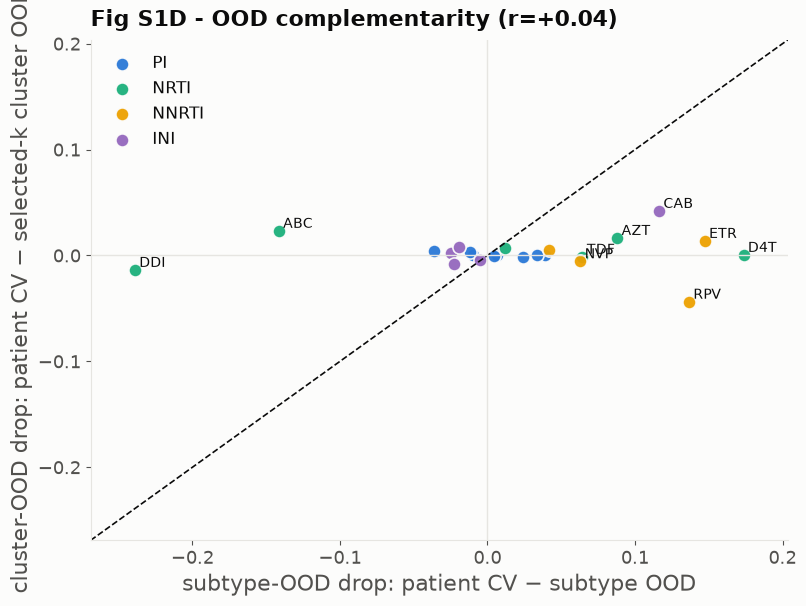

In [6]:
if PROTOCOL_CSV.exists():
    ood = pd.read_csv(PROTOCOL_CSV)
    ood_src = PROTOCOL_CSV
elif OOD_CSV.exists():
    ood = pd.read_csv(OOD_CSV)
    ood_src = OOD_CSV
else:
    raise FileNotFoundError(
        f'Missing fig3 outputs. Run notebooks/scripts/fig3_protocol_benchmark.py first.\n'
        f'Expected {PROTOCOL_CSV} or {OOD_CSV}'
    )

need = ['class', 'drug', 'rg_esm_lgb', 'clu_esm_lgb', 'ood_esm_lgb', 'rg_binary', 'ood_binary']
missing = [c for c in need if c not in ood.columns]
if missing:
    raise KeyError(f'{ood_src} missing columns: {missing}')

drop = ood.copy()
drop['subtype_drop'] = drop['rg_esm_lgb'] - drop['ood_esm_lgb']
drop['cluster_drop'] = drop['rg_esm_lgb'] - drop['clu_esm_lgb']
drop['binary_subtype_drop'] = drop['rg_binary'] - drop['ood_binary']
drop = drop.dropna(subset=['subtype_drop', 'cluster_drop']).copy()
corr = float(drop['subtype_drop'].corr(drop['cluster_drop']))
print('OOD source (read-only):', ood_src)
print(f'Pearson r(subtype_drop, cluster_drop) = {corr:+.3f}  n={len(drop)}')

drop_out = drop[['class', 'drug', 'subtype_drop', 'cluster_drop', 'binary_subtype_drop']].copy()
drop_out.to_csv(OUT_DIR / 'subtype_vs_selected_cluster_drop.csv', index=False)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
for cls in MAIN_CLASSES:
    d = drop[drop['class'] == cls]
    ax.scatter(d['subtype_drop'], d['cluster_drop'], s=90, color=CLASS_COLOR[cls],
               edgecolor=SURFACE, linewidth=1.2, alpha=0.95, label=cls)
for _, r in drop.iterrows():
    if abs(r['subtype_drop'] - r['cluster_drop']) > 0.06:
        ax.text(r['subtype_drop'] + 0.003, r['cluster_drop'] + 0.003, r['drug'], fontsize=10, color=INK)
lim_lo = min(drop['subtype_drop'].min(), drop['cluster_drop'].min(), 0) - 0.03
lim_hi = max(drop['subtype_drop'].max(), drop['cluster_drop'].max(), 0) + 0.03
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], '--', color=INK, lw=1.2)
ax.axhline(0, color=GRID, lw=1)
ax.axvline(0, color=GRID, lw=1)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel('subtype-OOD drop: patient CV − subtype OOD', fontsize=16)
ax.set_ylabel('cluster-OOD drop: patient CV − selected-k cluster OOD', fontsize=16)
ax.set_title(f'Fig S1D - OOD complementarity (r={corr:+.2f})', loc='left', fontsize=16, color=INK, pad=10, fontweight='bold')
ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=13)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1D_subtype_vs_selected_cluster_drop.png', dpi=150, bbox_inches='tight')
plt.show()


## Sensitivity · algorithm × k sweep

Formerly `figS1_cluster_sensitivity.py`: agglomerative / kmeans × k∈{5,10,20} cluster-OOD AUROC.  
Read cache by default; recompute when `RECOMPUTE_SENSITIVITY=True`. Writes only `work/results/cluster_sensitivity.csv`; does not touch fig3.


loaded cache → /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2/work/results/cluster_sensitivity.csv (138 rows)

=== MEAN cluster-OOD AUROC by (algo, k) ===
                  binary  esm_lr  esm_lgb
algo          k                          
agglomerative 5   0.8602  0.8853   0.8690
              10  0.8787  0.8988   0.8946
              20  0.8842  0.9014   0.9006
kmeans        5   0.8684  0.8902   0.8817
              10  0.8790  0.8968   0.8980
              20  0.8853  0.9006   0.9008
  agglomerative k= 5: esm_lr  (lgb-lr=-0.0163)
  agglomerative k=10: esm_lr  (lgb-lr=-0.0042)
  agglomerative k=20: esm_lr  (lgb-lr=-0.0008)
  kmeans        k= 5: esm_lr  (lgb-lr=-0.0085)
  kmeans        k=10: esm_lgb  (lgb-lr=+0.0012)
  kmeans        k=20: esm_lgb  (lgb-lr=+0.0002)
saved /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2/figures/manuscript/supp_cluster/figS1_cluster_sensitivity.png


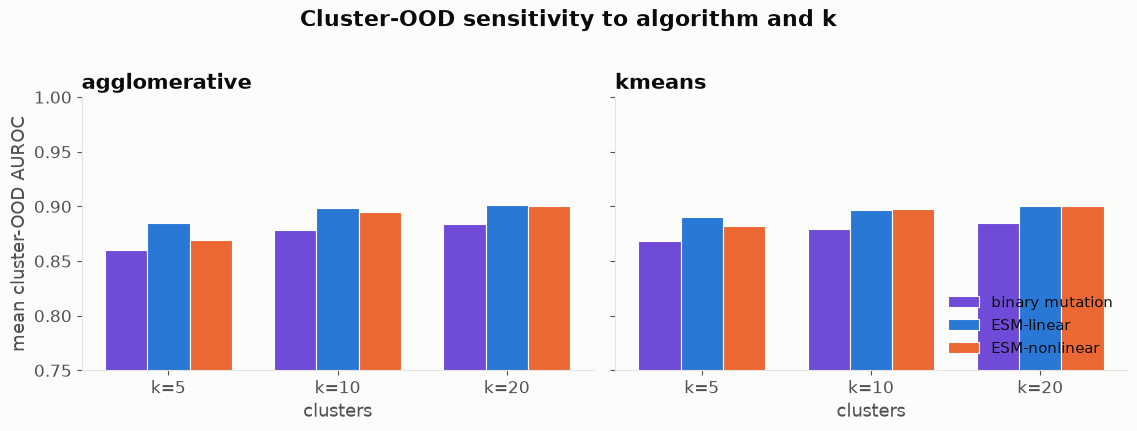

In [7]:
RECOMPUTE_SENSITIVITY = False
N_CLUSTERS = [5, 10, 20]
ALGOS = ['agglomerative', 'kmeans']


def binenc(seqs, ref):
    length = min(min(len(s) for s in seqs), len(ref))
    return np.array([[1.0 if s[j] != ref[j] else 0.0 for j in range(length)] for s in seqs], dtype=np.float32)


def fit_pred(kind: str, is_bin: bool, xtr, ytr, xte):
    if kind == 'lgb':
        model = lgb.LGBMClassifier(
            n_estimators=150, num_leaves=15, learning_rate=0.08,
            random_state=42, deterministic=True, force_col_wise=True, n_jobs=1, verbose=-1,
        )
    else:
        model = make_pipeline(
            StandardScaler(with_mean=not is_bin),
            LogisticRegression(max_iter=2000, class_weight='balanced'),
        )
    model.fit(xtr, ytr)
    return model.predict_proba(xte)[:, 1]


def cluster_part(emb, algo: str, k: int):
    k_eff = min(k, max(2, len(emb) // 20))
    if algo == 'kmeans':
        return KMeans(n_clusters=k_eff, n_init=10, random_state=42).fit_predict(emb)
    return AgglomerativeClustering(n_clusters=k_eff).fit_predict(emb)


def loco(kind: str, is_bin: bool, X, y, clu):
    oof = np.full(len(y), np.nan)
    for c in np.unique(clu):
        te = clu == c
        tr = ~te
        if len(np.unique(y[tr])) < 2 or te.sum() < 3 or len(np.unique(y[te])) < 1:
            continue
        oof[te] = fit_pred(kind, is_bin, X[tr], y[tr], X[te])
    mask = ~np.isnan(oof)
    if mask.sum() > 10 and len(np.unique(y[mask])) == 2:
        return float(roc_auc_score(y[mask], oof[mask]))
    return np.nan


def run_cluster_sensitivity() -> pd.DataFrame:
    refs = build_refs()
    cache = {}
    rows = []
    for cls, drugs in DRUGS.items():
        gene = GENE_OF[cls]
        if gene not in cache:
            cache[gene] = load_emb(gene)
        idx, mean = cache[gene]
        ref = refs[gene]
        df = pd.read_csv(PREP / f'{cls}.csv', dtype={'SeqID': str})
        seqs = df['sequence'].tolist()
        emb_row = np.array([idx.get(s, -1) for s in seqs])
        xb_all = binenc(seqs, ref)
        for drug in drugs:
            y = pd.to_numeric(df[f'{drug}_label'], errors='coerce').to_numpy()
            valid = (~np.isnan(y)) & (emb_row >= 0)
            yv = y[valid].astype(int)
            if len(np.unique(yv)) < 2:
                continue
            r = emb_row[valid]
            xb, xe = xb_all[valid], mean[r]
            for algo in ALGOS:
                for k in N_CLUSTERS:
                    clu = cluster_part(xe, algo, k)
                    rows.append({
                        'class': cls, 'drug': drug, 'algo': algo, 'k': k,
                        'binary': loco('lr', True, xb, yv, clu),
                        'esm_lr': loco('lr', False, xe, yv, clu),
                        'esm_lgb': loco('lgb', False, xe, yv, clu),
                    })
            print(f'  {cls}/{drug} done', flush=True)
    return pd.DataFrame(rows)


if (not RECOMPUTE_SENSITIVITY) and SENS_CSV.exists():
    sens = pd.read_csv(SENS_CSV)
    print(f'loaded cache → {SENS_CSV} ({len(sens)} rows)')
else:
    print('computing sensitivity sweep ...', flush=True)
    sens = run_cluster_sensitivity()
    SENS_CSV.parent.mkdir(parents=True, exist_ok=True)
    sens.to_csv(SENS_CSV, index=False)
    print(f'saved → {SENS_CSV}')

sens_mean = sens.groupby(['algo', 'k'])[['binary', 'esm_lr', 'esm_lgb']].mean().round(4)
print('\n=== MEAN cluster-OOD AUROC by (algo, k) ===')
print(sens_mean.to_string())
for (algo, k), row in sens_mean.iterrows():
    best = row.idxmax()
    print(f'  {algo:13s} k={int(k):2d}: {best}  (lgb-lr={row.esm_lgb - row.esm_lr:+.4f})')

plot_df = sens_mean.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, algo in zip(axes, ALGOS):
    sub = plot_df[plot_df['algo'] == algo]
    x = np.arange(len(sub))
    width = 0.25
    for i, method in enumerate(['binary', 'esm_lr', 'esm_lgb']):
        ax.bar(x + (i - 1) * width, sub[method], width=width, color=M_COLOR[method],
               label=M_LABEL[method], edgecolor=SURFACE, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={int(v)}" for v in sub['k']])
    ax.set_title(algo, loc='left', fontsize=15, fontweight='bold', color=INK)
    ax.set_xlabel('clusters', fontsize=13)
    ax.set_ylim(0.75, 1.0)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(labelsize=12)
axes[0].set_ylabel('mean cluster-OOD AUROC', fontsize=13)
axes[1].legend(frameon=False, fontsize=11, loc='lower right')
fig.suptitle('Cluster-OOD sensitivity to algorithm and k', fontsize=16, fontweight='bold', color=INK, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1_cluster_sensitivity.png', dpi=150, bbox_inches='tight')
print('saved', FIG_DIR / 'figS1_cluster_sensitivity.png')
plt.show()


## Combined Figure S1


saved /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2/figures/manuscript/supp_cluster/figS1_combined.png


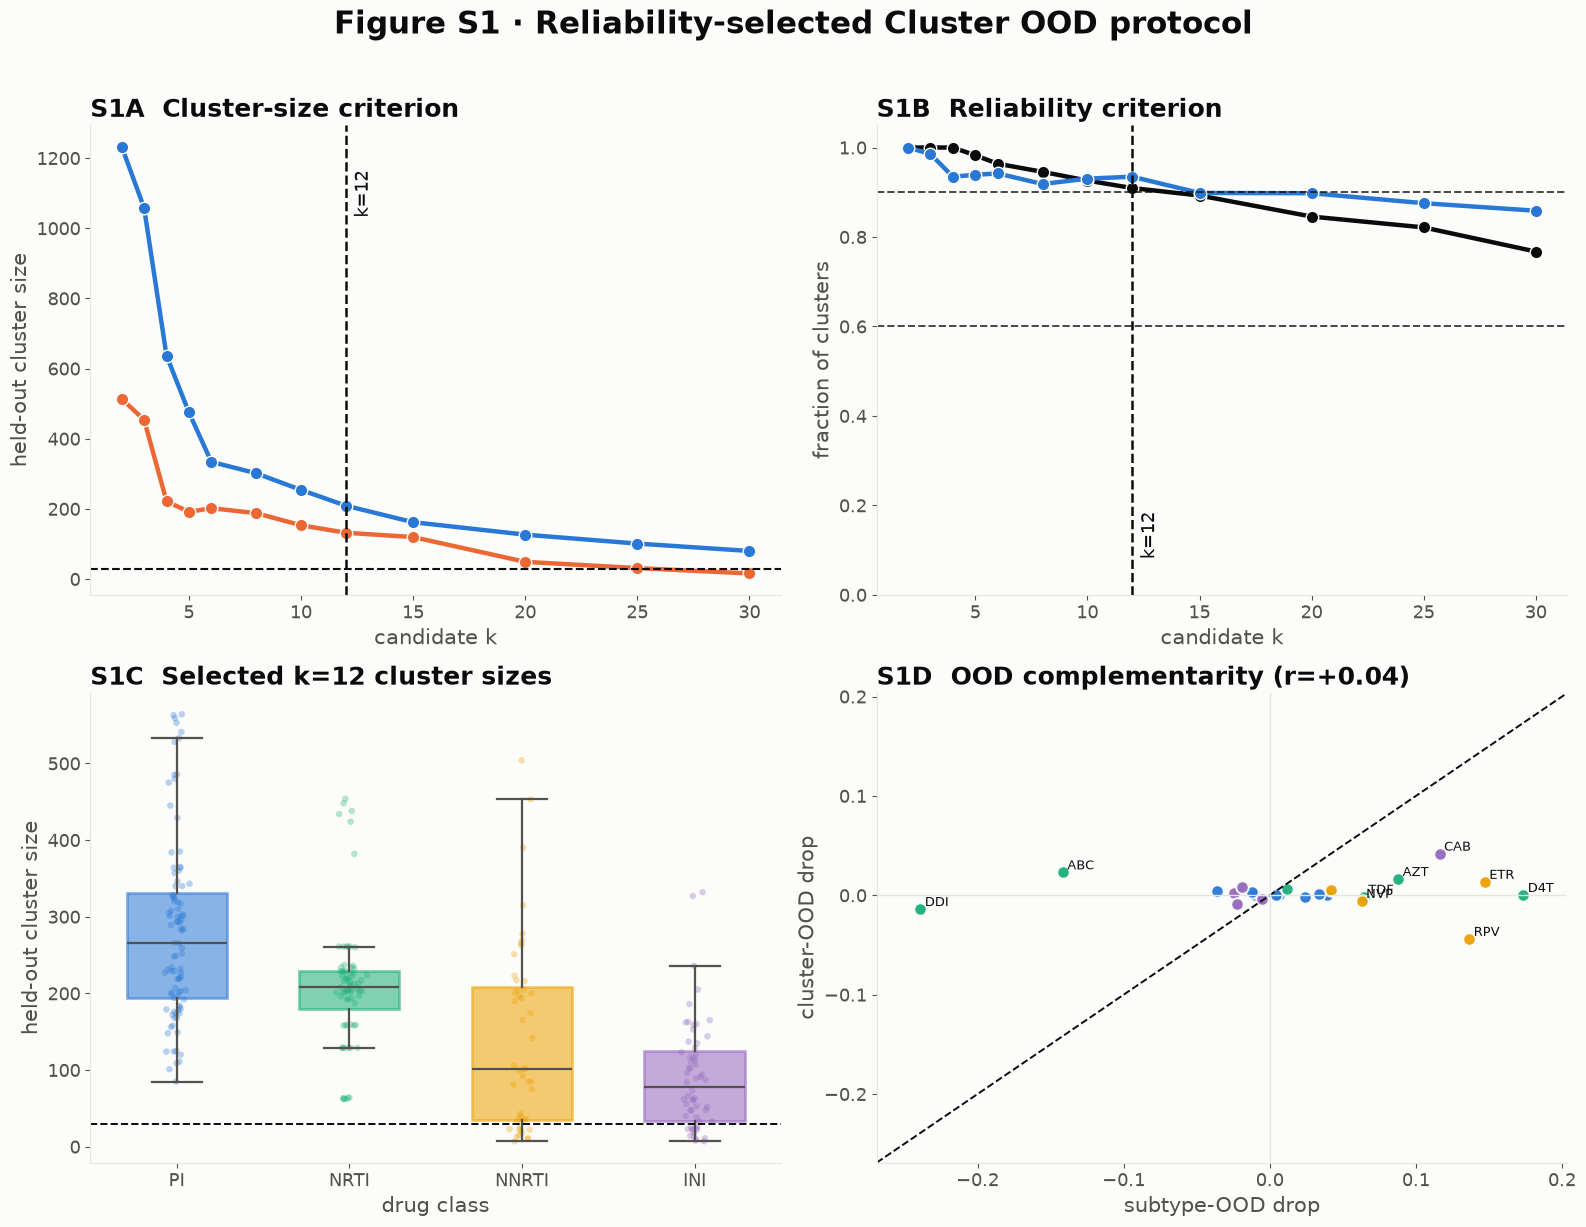

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
ax.plot(metrics['k'], metrics['median_cluster_size'], '-o', lw=3.2, ms=9, color='#2a78d6', markeredgecolor=SURFACE)
ax.plot(metrics['k'], metrics['p10_cluster_size'], '-o', lw=3.2, ms=9, color='#eb6834', markeredgecolor=SURFACE)
ax.axhline(30, color=INK, lw=1.5, ls='--')
ax.axvline(K_STAR, color=INK, lw=1.8, ls='--')
ax.text(K_STAR + 0.35, ax.get_ylim()[1] * 0.90, f'k={K_STAR}', rotation=90, va='top', ha='left', fontsize=13, color=INK)
ax.set_title('S1A  Cluster-size criterion', loc='left', fontsize=18, fontweight='bold', color=INK)
ax.set_xlabel('candidate k', fontsize=15)
ax.set_ylabel('held-out cluster size', fontsize=15)

ax = axes[0, 1]
ax.plot(metrics['k'], metrics['frac_clusters_ge30'], '-o', lw=3.2, ms=9, color=INK, markeredgecolor=SURFACE)
ax.plot(metrics['k'], metrics['frac_clusters_both_classes'], '-o', lw=3.2, ms=9, color='#2a78d6', markeredgecolor=SURFACE)
ax.axhline(0.90, color=INK, lw=1.4, ls='--', alpha=0.75)
ax.axhline(0.60, color=INK, lw=1.4, ls='--', alpha=0.75)
ax.axvline(K_STAR, color=INK, lw=1.8, ls='--')
ax.text(K_STAR + 0.35, 0.08, f'k={K_STAR}', rotation=90, va='bottom', ha='left', fontsize=13, color=INK)
ax.set_ylim(0, 1.05)
ax.set_title('S1B  Reliability criterion', loc='left', fontsize=18, fontweight='bold', color=INK)
ax.set_xlabel('candidate k', fontsize=15)
ax.set_ylabel('fraction of clusters', fontsize=15)

ax = axes[1, 0]
data = [cluster_sizes.loc[cluster_sizes['class'] == cls, 'cluster_size'].values for cls in MAIN_CLASSES]
bp = ax.boxplot(data, patch_artist=True, widths=0.58, showfliers=False)
ax.set_xticks(range(1, len(MAIN_CLASSES) + 1))
ax.set_xticklabels(MAIN_CLASSES)
for box, cls in zip(bp['boxes'], MAIN_CLASSES):
    box.set_facecolor(CLASS_COLOR[cls]); box.set_alpha(0.55); box.set_edgecolor(CLASS_COLOR[cls]); box.set_linewidth(2.0)
for key in ['whiskers', 'caps', 'medians']:
    for obj in bp[key]:
        obj.set_color(INK2); obj.set_linewidth(1.6)
rng = np.random.default_rng(42)
for i, cls in enumerate(MAIN_CLASSES, 1):
    vals = cluster_sizes.loc[cluster_sizes['class'] == cls, 'cluster_size'].values
    ax.scatter(rng.normal(i, 0.035, len(vals)), vals, s=22, color=CLASS_COLOR[cls], alpha=0.32, edgecolor='none')
ax.axhline(30, color=INK, lw=1.4, ls='--')
ax.set_title(f'S1C  Selected k={K_STAR} cluster sizes', loc='left', fontsize=18, fontweight='bold', color=INK)
ax.set_xlabel('drug class', fontsize=15)
ax.set_ylabel('held-out cluster size', fontsize=15)

ax = axes[1, 1]
for cls in MAIN_CLASSES:
    d = drop[drop['class'] == cls]
    ax.scatter(d['subtype_drop'], d['cluster_drop'], s=80, color=CLASS_COLOR[cls], edgecolor=SURFACE, linewidth=1.4, alpha=0.95)
for _, r in drop.iterrows():
    if abs(r['subtype_drop'] - r['cluster_drop']) > 0.06:
        ax.text(r['subtype_drop'] + 0.003, r['cluster_drop'] + 0.003, r['drug'], fontsize=9, color=INK)
lim_lo = min(drop['subtype_drop'].min(), drop['cluster_drop'].min(), 0) - 0.03
lim_hi = max(drop['subtype_drop'].max(), drop['cluster_drop'].max(), 0) + 0.03
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], '--', color=INK, lw=1.4)
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_title(f'S1D  OOD complementarity (r={corr:+.2f})', loc='left', fontsize=18, fontweight='bold', color=INK)
ax.set_xlabel('subtype-OOD drop', fontsize=15)
ax.set_ylabel('cluster-OOD drop', fontsize=15)

for ax in axes.ravel():
    ax.tick_params(labelsize=13)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.suptitle('Figure S1 · Reliability-selected Cluster OOD protocol', fontsize=22, fontweight='bold', y=1.02, color=INK)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figS1_combined.png', dpi=180, bbox_inches='tight')
print('saved', FIG_DIR / 'figS1_combined.png')
plt.show()


## Artifact inventory

| Panel | Figure | Written by this notebook | Reads fig3 |
|---|---|---|---|
| Analysis | — | `selected_cluster_k.csv`, `k_reliability_*.csv`, `cluster_sizes_*.csv` | no |
| S1A–C | `figures/manuscript/supp_cluster/figS1{A,B,C}_*.png` | same as above | no |
| S1D | `figS1D_subtype_vs_selected_cluster_drop.png` | `subtype_vs_selected_cluster_drop.csv` | **yes** (protocol/ood) |
| Sensitivity | `figS1_cluster_sensitivity.png` | `work/results/cluster_sensitivity.csv` | no |
| Combined | `figS1_combined.png` | — | — |

**Never write**: `work/results/probe_protocol_full_selected_k.csv`, `work/results/probe_ood_full_selected_k.csv` (fig3 exclusive).
